Metrics visualisation

# Libraries

In [51]:
import os
from pathlib import Path
import seaborn as sns
import joblib
import matplotlib.pyplot as plt
import pandas as pd

# Data load

In [8]:
df_metrics = pd.read_excel('../results/metrics_modelling2_highlight.xlsx')
df_metrics = df_metrics[
    df_metrics['dataset']=='df_modelling_dimensionless'].drop_duplicates()

## Splashing data

In [38]:
df_spalshing = df_metrics[df_metrics['target']=='splashing']
df_spalshing = df_spalshing.sort_values(by=['f1', 'roc_auc'], ascending=False).loc[
    [51, 59, 44, 41, 52]]
df_spalshing['model'] = df_spalshing['model'].apply(lambda x: x.split('_')[0])
df_spalshing = df_spalshing.iloc[: ,2:]
df_spalshing['model'] = df_spalshing['model'].map({
    'kneighborsclassifier': 'KNClassifier',
    'catboostclassifier': 'CatBoost',
    'svc': 'SVC',
    'logisticregression': 'Logistic Regression',
    'xgbclassifier': 'XGB-classifier'})
df_spalshing.rename(columns={'model': 'Model',
                             'accuracy': 'Accuracy',
                             'f1': 'F1',
                             'precision': 'Precision',
                             'recall': 'Recall',
                             'roc_auc': 'ROC AUC'}, inplace=True)
df_spalshing = df_spalshing.round(3)
df_spalshing['Target'] = 'Splashing'
df_spalshing

,Model,Accuracy,F1,Precision,Recall,ROC AUC,Target
51,KNClassifier,0.867,0.900,0.865,0.938,0.839,Splashing
59,CatBoost,0.867,0.900,0.865,0.938,0.839,Splashing
44,SVC,0.853,0.889,0.863,0.917,0.829,Splashing
41,Logistic Regression,0.840,0.880,0.846,0.917,0.810,Splashing
52,XGB-classifier,0.840,0.880,0.846,0.917,0.810,Splashing


## Net impact data

In [39]:
df_net_impact = df_metrics[df_metrics['target']=='net_impact']
df_net_impact = df_net_impact.sort_values(by=['f1', 'roc_auc'], ascending=False).loc[
    [22, 63, 104, 111, 155]]
df_net_impact['model'] = df_net_impact['model'].apply(lambda x: x.split('_')[0])
df_net_impact = df_net_impact.iloc[: ,2:]
df_net_impact['model'] = df_net_impact['model'].map({
    'kneighborsclassifier': 'KNClassifier',
    'catboostclassifier': 'CatBoost',
    'svc': 'SVC',
    'logisticregression': 'Logistic Regression',
    'xgbclassifier': 'XGB-classifier'})
df_net_impact.rename(columns={'model': 'Model',
                             'accuracy': 'Accuracy',
                             'f1': 'F1',
                             'precision': 'Precision',
                             'recall': 'Recall',
                             'roc_auc': 'ROC AUC'}, inplace=True)
df_net_impact = df_net_impact.round(3)
df_net_impact['Target'] = 'Net impact'
df_net_impact

,Model,Accuracy,F1,Precision,Recall,ROC AUC,Target
22,CatBoost,0.947,0.900,0.900,0.90,0.932,Net impact
63,XGB-classifier,0.920,0.842,0.889,0.80,0.882,Net impact
104,SVC,0.880,0.800,0.720,0.90,0.886,Net impact
111,KNClassifier,0.880,0.791,0.739,0.85,0.870,Net impact
155,Logistic Regression,0.880,0.769,0.789,0.75,0.839,Net impact


In [56]:
df_net_impact

,Model,Accuracy,F1,Precision,Recall,ROC AUC,Target
22,CatBoost,0.947,0.900,0.900,0.90,0.932,Net impact
63,XGB-classifier,0.920,0.842,0.889,0.80,0.882,Net impact
104,SVC,0.880,0.800,0.720,0.90,0.886,Net impact
111,KNClassifier,0.880,0.791,0.739,0.85,0.870,Net impact
155,Logistic Regression,0.880,0.769,0.789,0.75,0.839,Net impact


# Data plot

In [83]:
path_visualisations = Path('../results/metrics_visualisation/')
if not os.path.exists(path_visualisations): os.makedirs(path_visualisations)

## Net impact

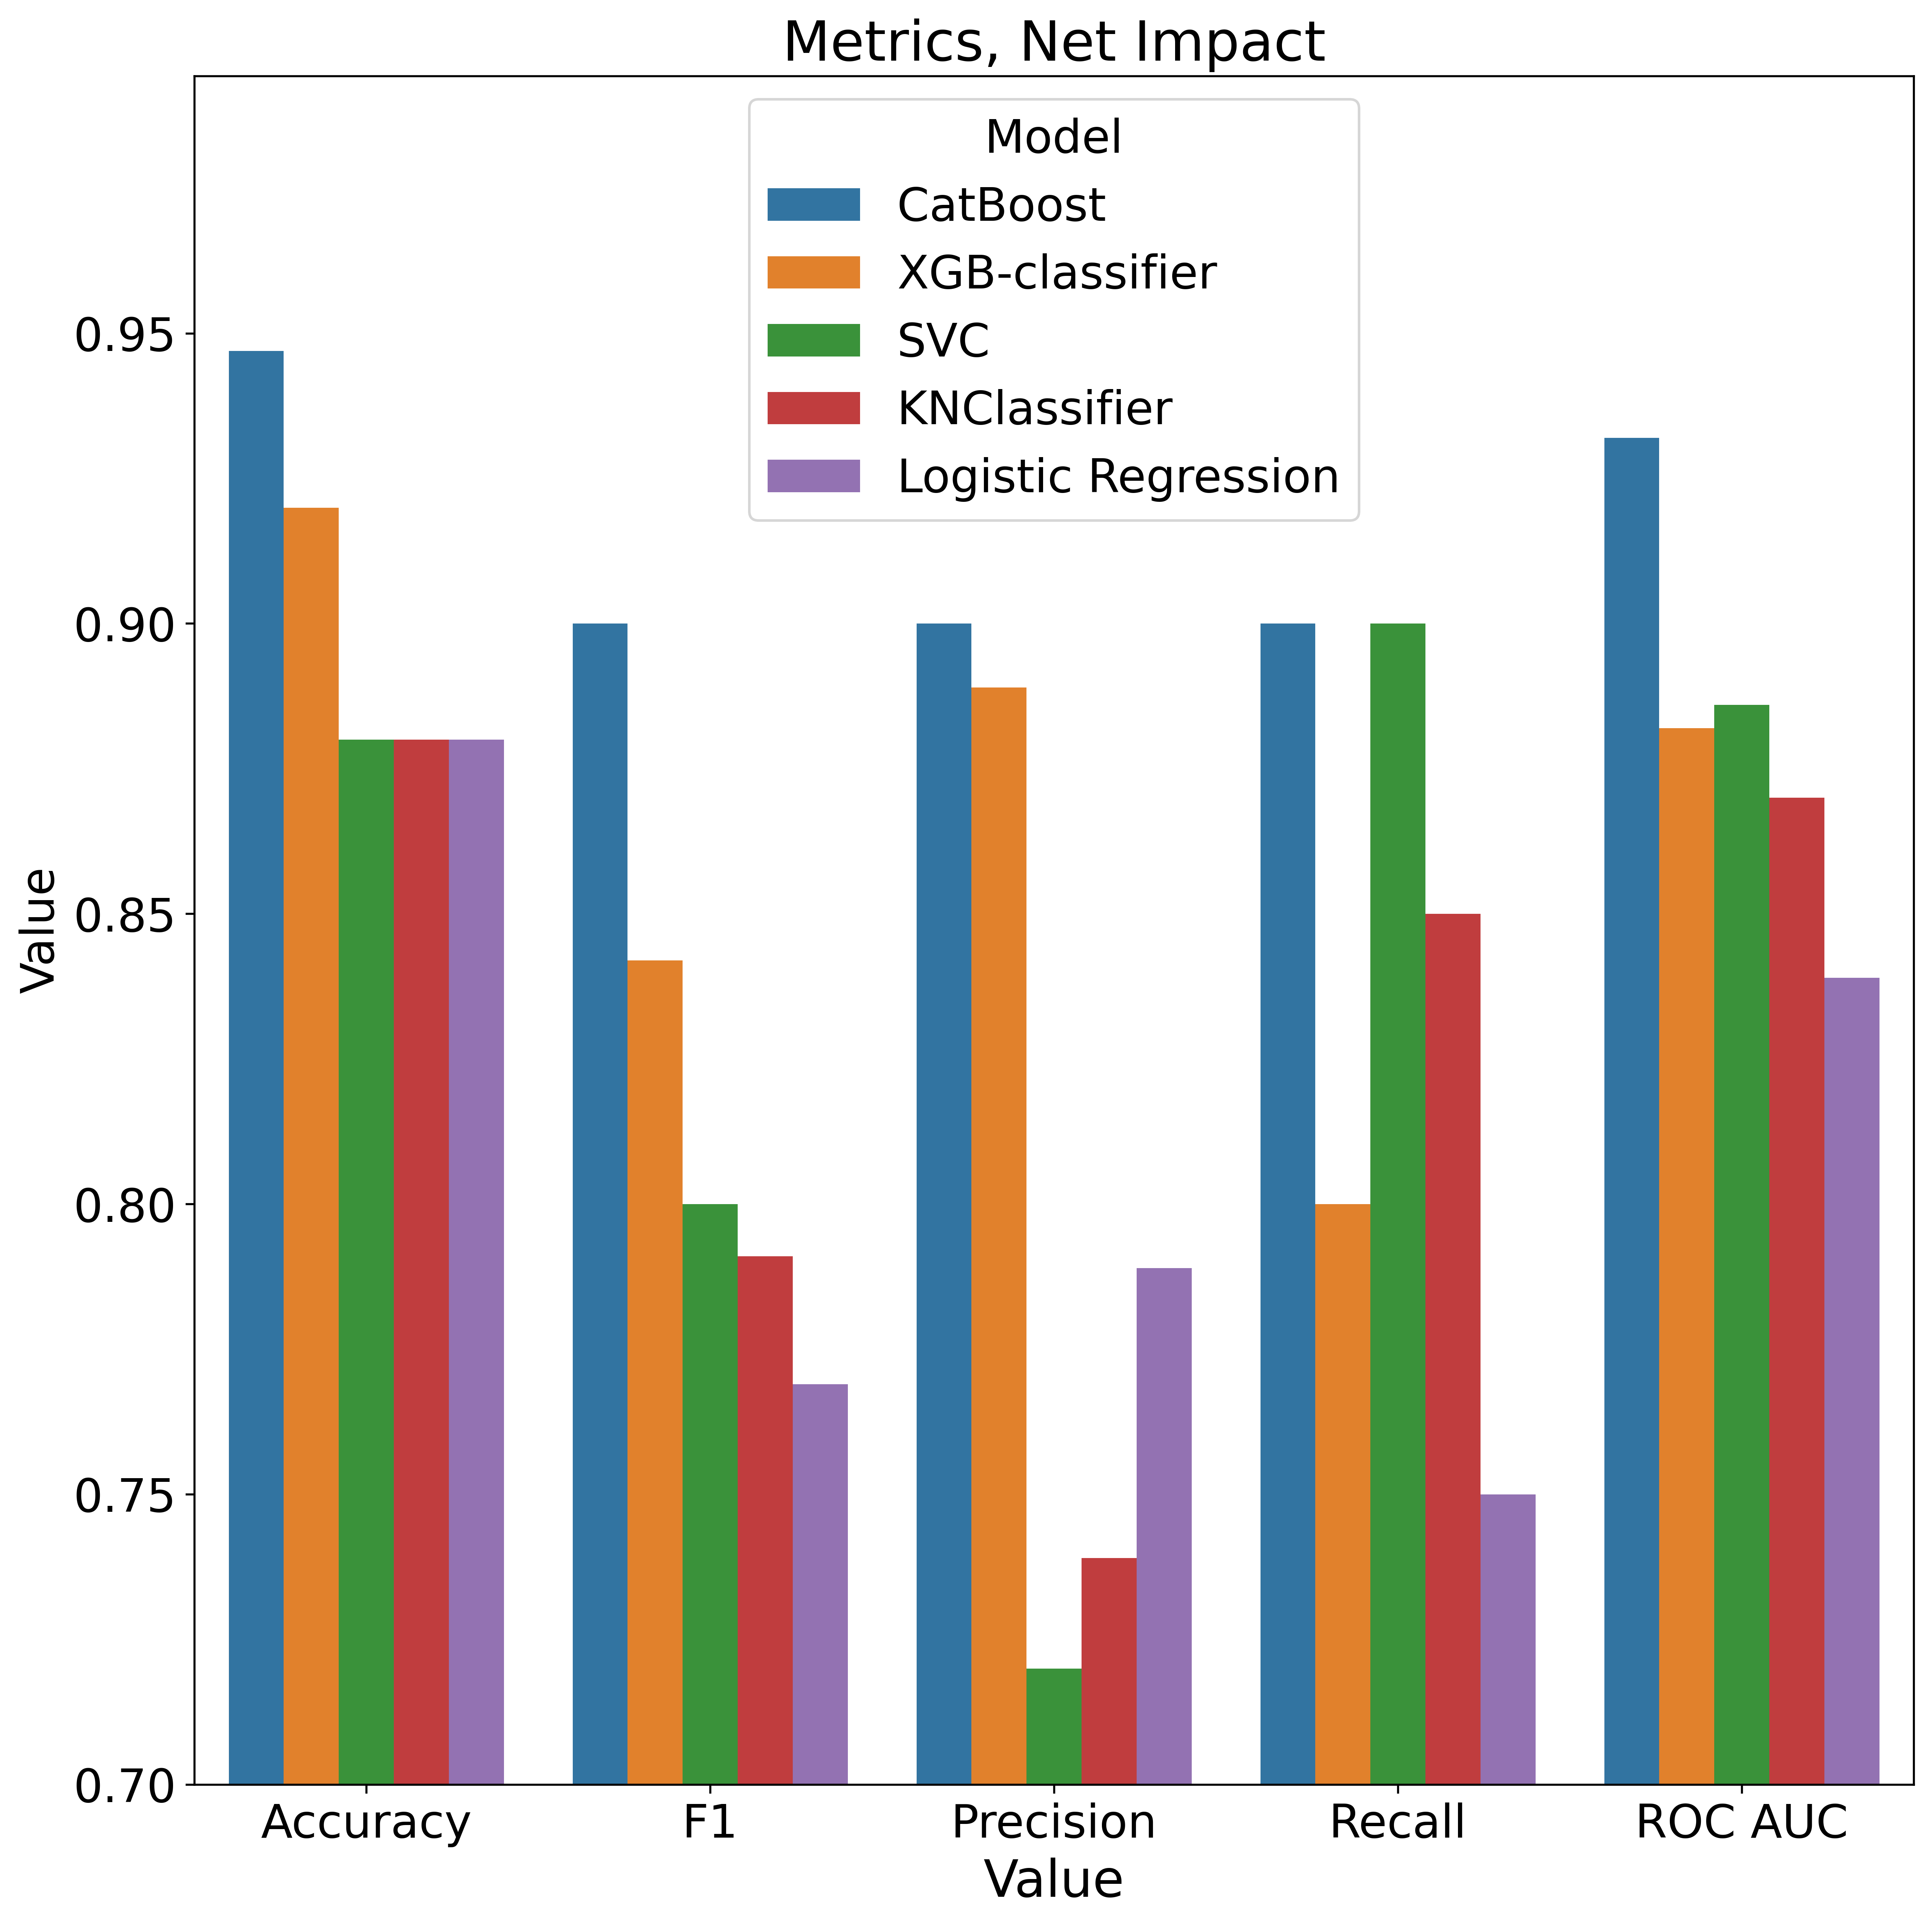

In [84]:
df_melted_net = pd.melt(df_net_impact.iloc[:, :-1], id_vars=['Model'],
        var_name='Metric', value_name='Value')
plt.figure(figsize=(12, 12), dpi=500)
ax = sns.barplot(df_melted_net,
            x='Metric', y='Value', hue='Model')
plt.rcParams.update({'font.size': 18})
plt.title('Metrics, Net Impact')
plt.xlabel('Metric', fontsize=20)
plt.xlabel('Value', fontsize=20)
plt.ylim(0.7, plt.ylim()[1])
plt.savefig(path_visualisations / f'net_impact_metrics.pdf', bbox_inches='tight')
plt.show()

## Splashing

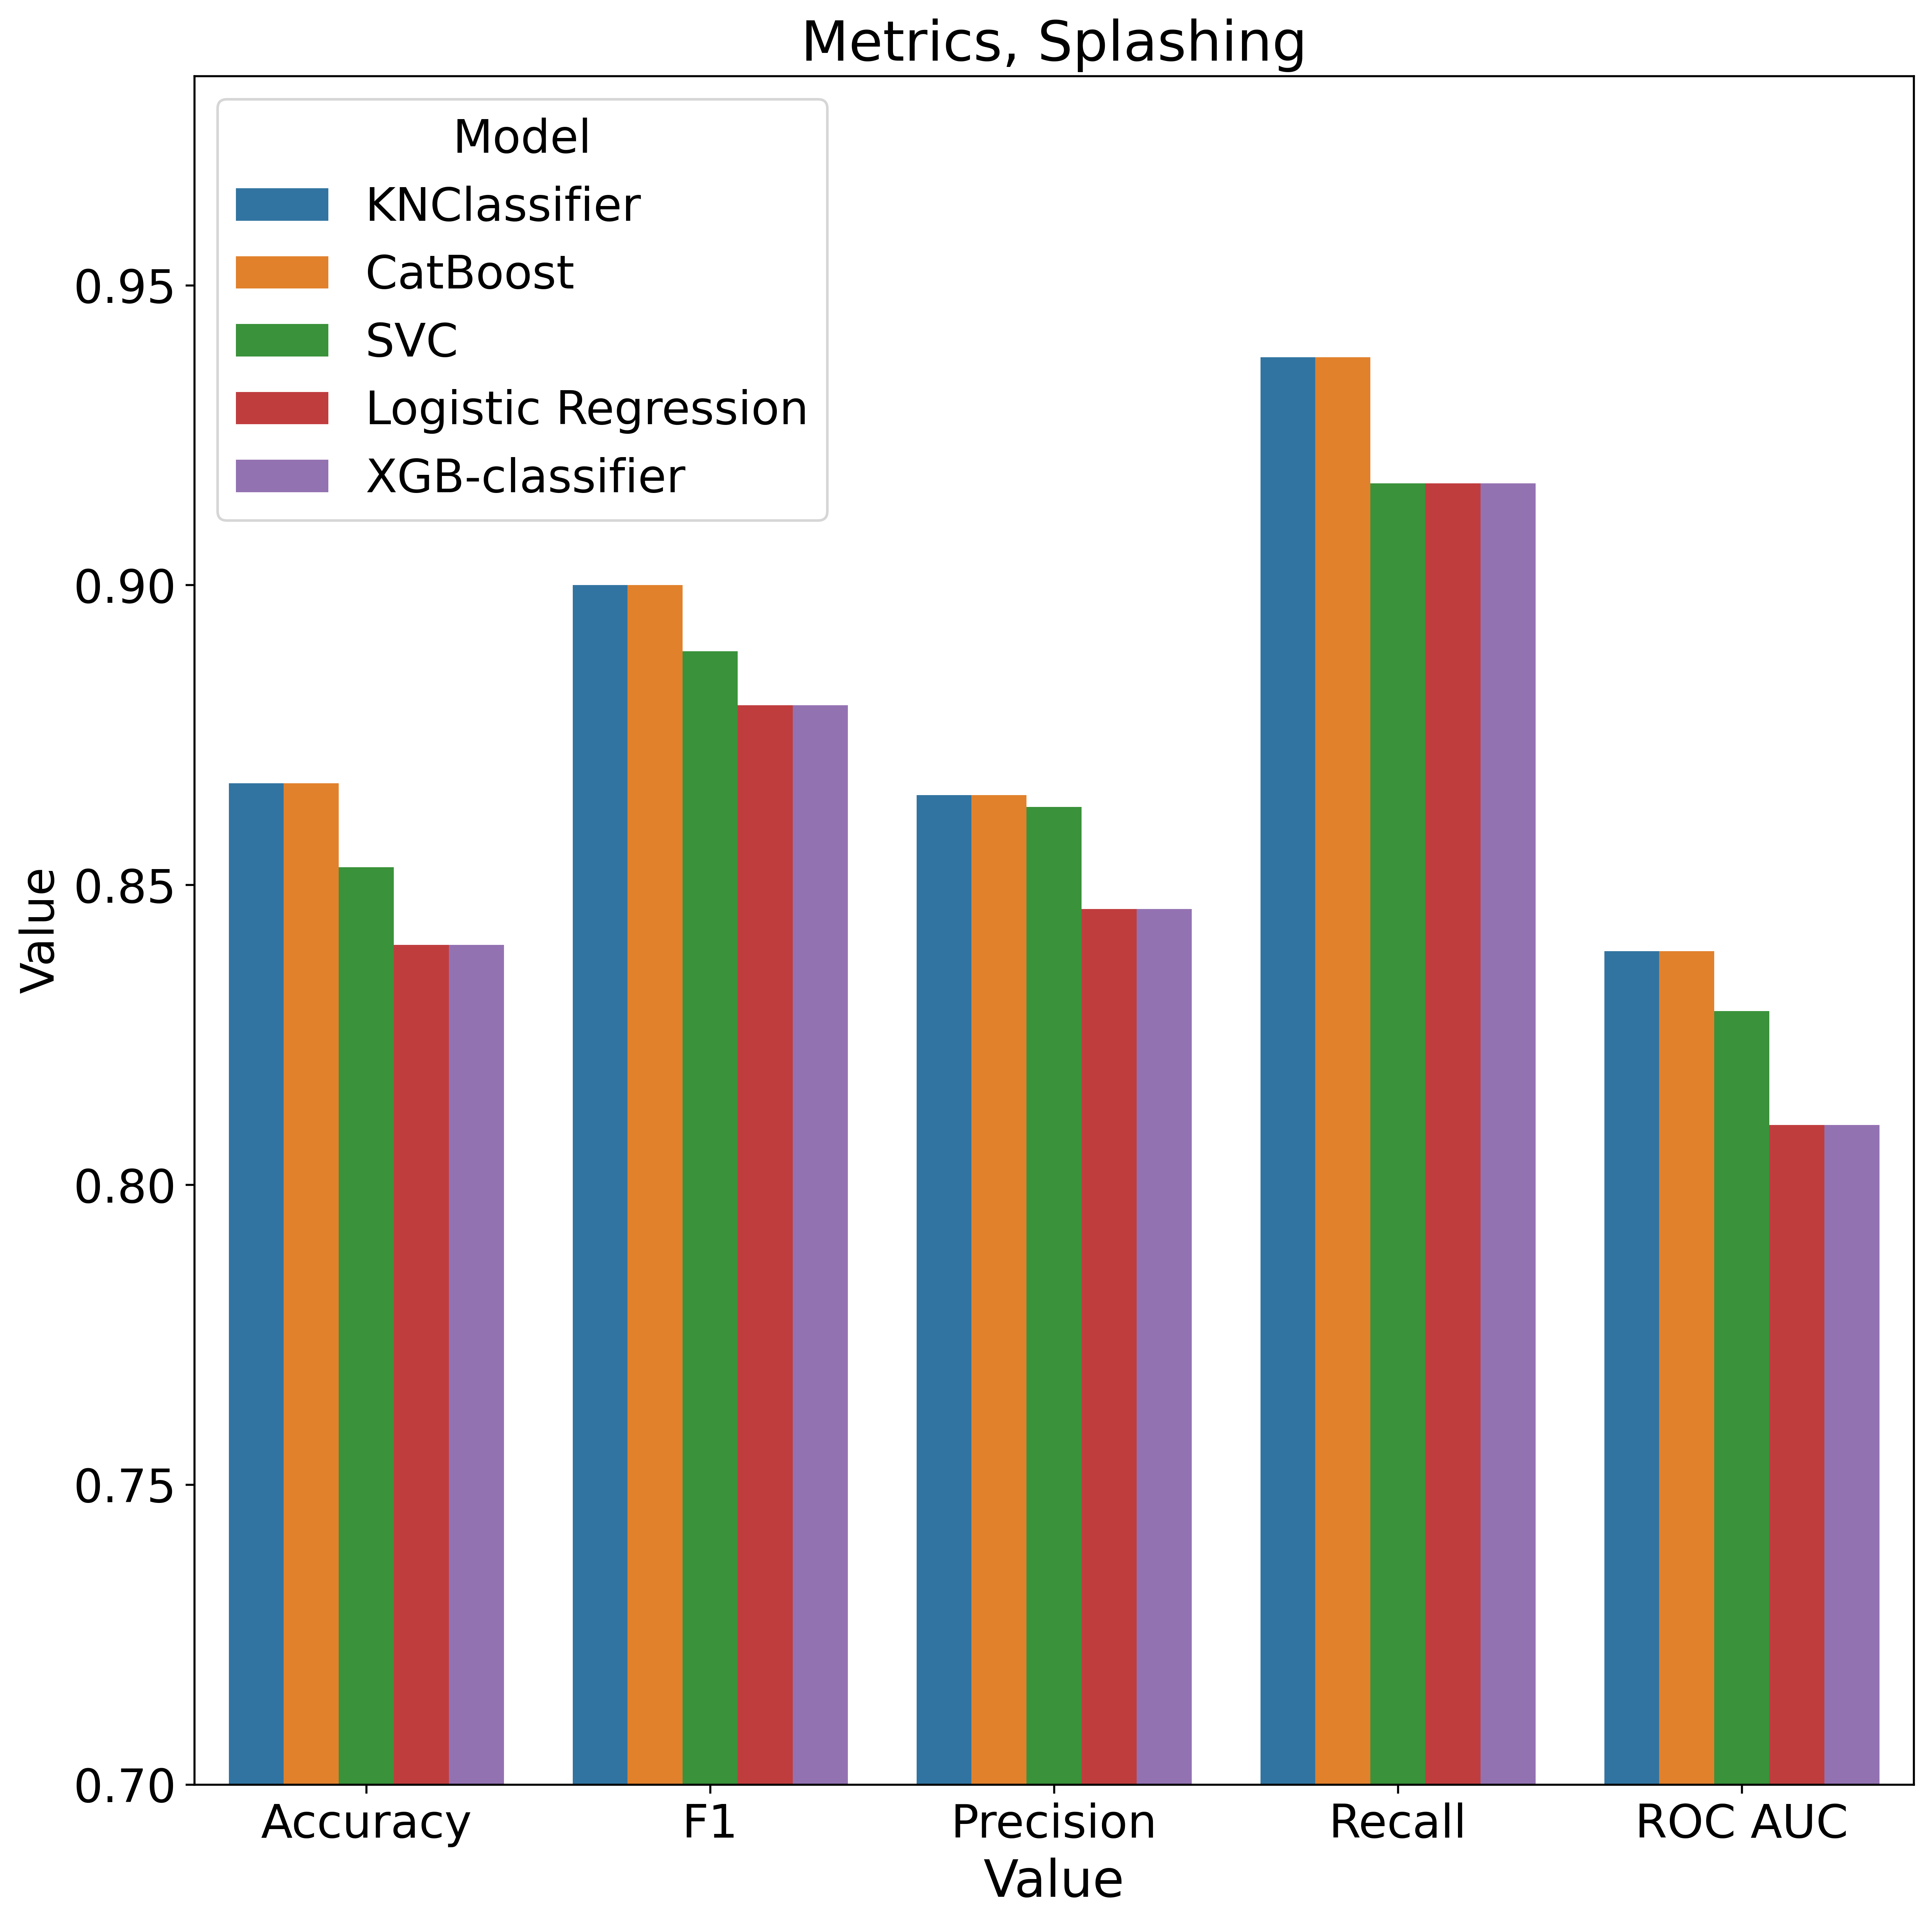

In [86]:
df_melted_splashing = pd.melt(df_spalshing.iloc[:, :-1], id_vars=['Model'],
        var_name='Metric', value_name='Value')
plt.figure(figsize=(12, 12), dpi=500)
ax = sns.barplot(df_melted_splashing,
            x='Metric', y='Value', hue='Model')
plt.rcParams.update({'font.size': 18})
plt.title('Metrics, Splashing')
plt.xlabel('Metric', fontsize=20)
plt.xlabel('Value', fontsize=20)
plt.ylim(0.7, plt.ylim()[1])
plt.savefig(path_visualisations / f'splashing_metrics.pdf', bbox_inches='tight')
plt.show()